# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [29]:
#!pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.0 MB 14.8 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 25.5 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 19.6 MB/s  0:00:00

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-l

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
data_path = "House_Rent_Dataset.csv"
data = pd.read_csv(data_path)

In [5]:
data.shape

(4746, 12)

In [6]:
data.head(5)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [8]:
#Аналіз пропущених значень.
missing_data = data.isnull().sum()
missing_percent = (missing_data / len(data)) * 100

missing_percent

Posted On            0.0
BHK                  0.0
Rent                 0.0
Size                 0.0
Floor                0.0
Area Type            0.0
Area Locality        0.0
City                 0.0
Furnishing Status    0.0
Tenant Preferred     0.0
Bathroom             0.0
Point of Contact     0.0
dtype: float64

Пропущенні значення відсутні


In [9]:
#Базова статистика
stats = data.describe()
stats.round(2)

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


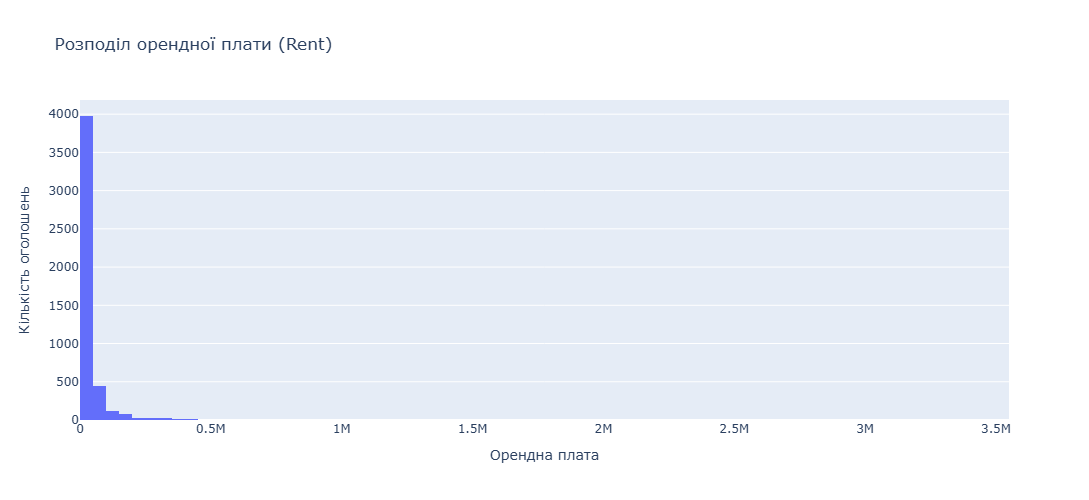

In [10]:
#Аналіз цільової змінної. 
fig = px.histogram(
    data,
    x='Rent',
    nbins=100,
    title='Розподіл орендної плати (Rent)'
)

fig.update_layout(
    xaxis_title='Орендна плата',
    yaxis_title='Кількість оголошень',
    showlegend=False,
    height=500
)

fig.show()

In [11]:
#Робота з викидами
Q1 = data['Rent'].quantile(0.25)
Q3 = data['Rent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Нижня межа: {lower_bound}")
print(f"Верхня межа: {upper_bound}")

data_cleaned = data[(data['Rent'] >= lower_bound) & (data['Rent'] <= upper_bound)]

print(f"Розмір початкового датасету: {data.shape}")
print(f"Розмір після очищення: {data_cleaned.shape}")
print(f"Видалено рядків: {len(data) - len(data_cleaned)}")

Нижня межа: -24500.0
Верхня межа: 67500.0
Розмір початкового датасету: (4746, 12)
Розмір після очищення: (4226, 12)
Видалено рядків: 520


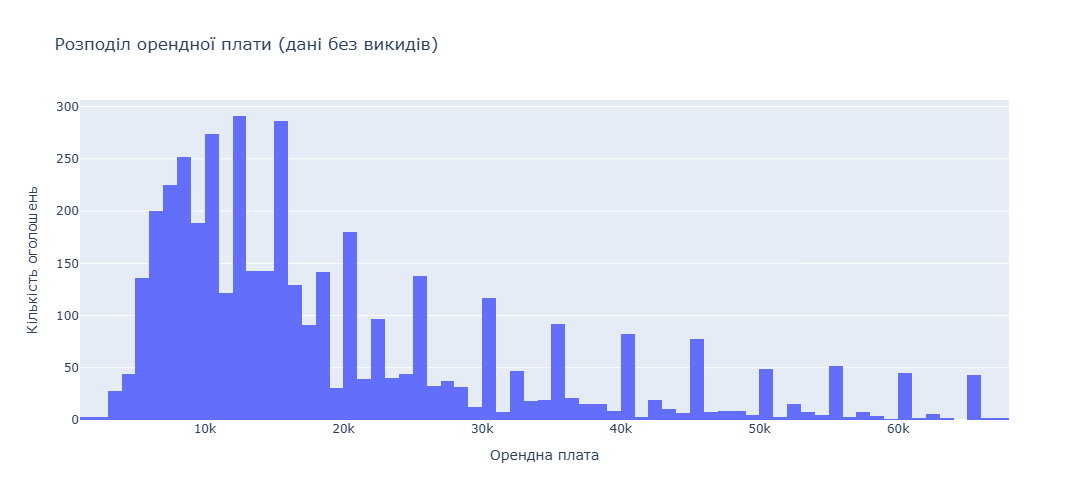

In [12]:
fig = px.histogram(
    data_cleaned,
    x='Rent',
    nbins=100,
    title='Розподіл орендної плати (дані без викидів)'
)

fig.update_layout(
    xaxis_title='Орендна плата',
    yaxis_title='Кількість оголошень',
    showlegend=False,
    height=500
)

fig.show()

In [13]:
#Аналіз категоріальних змінних
categorical_columns = data_cleaned.select_dtypes(include=['str']).columns
unique_counts = data_cleaned[categorical_columns].nunique()

print("Кількість унікальних значень у категоріальних колонках:")
print(unique_counts)

Кількість унікальних значень у категоріальних колонках:
Posted On              80
Floor                 340
Area Type               3
Area Locality        1997
City                    6
Furnishing Status       3
Tenant Preferred        3
Point of Contact        3
dtype: int64



## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


In [14]:
#Обчисліть матрицю кореляцій для числових змінних
metrics_data = data_cleaned.select_dtypes(include=['number']).corr()

# Матриця кореляцій
correlation_matrix = metrics_data.corr()
correlation_matrix

,BHK,Rent,Size,Bathroom
BHK,1.000000,-0.858862,0.493102,0.563711
Rent,-0.858862,1.000000,-0.855965,-0.609435
Size,0.493102,-0.855965,1.000000,0.318994
Bathroom,0.563711,-0.609435,0.318994,1.000000


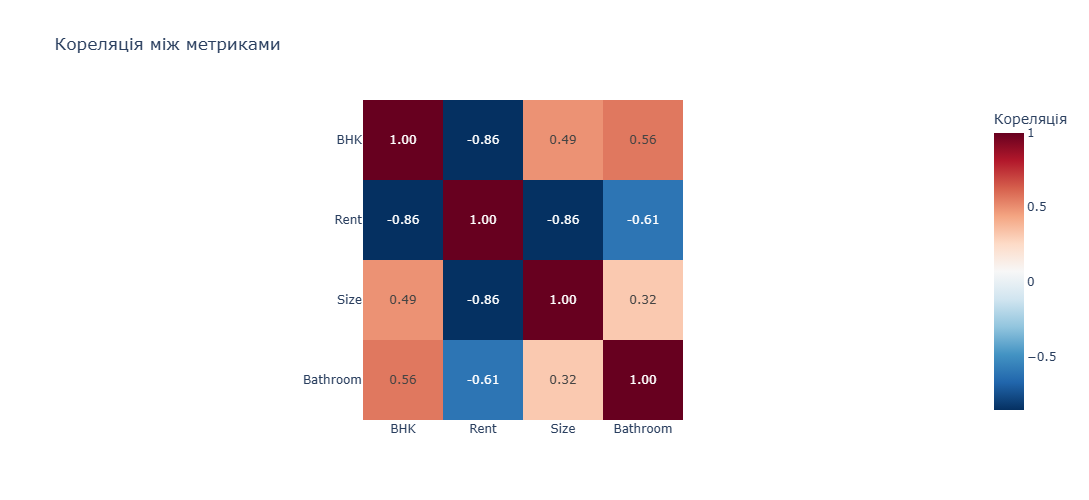

In [15]:
#Візуалізуйте кореляційну матрицю за допомогою heatmap
fig = px.imshow(
    correlation_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Кореляція між метриками',
    labels=dict(color="Кореляція")
)
fig.update_layout(height=500)
fig.show()

Найсильніша кореляція між Size та Rent. А також, між Bathroom та Rent.

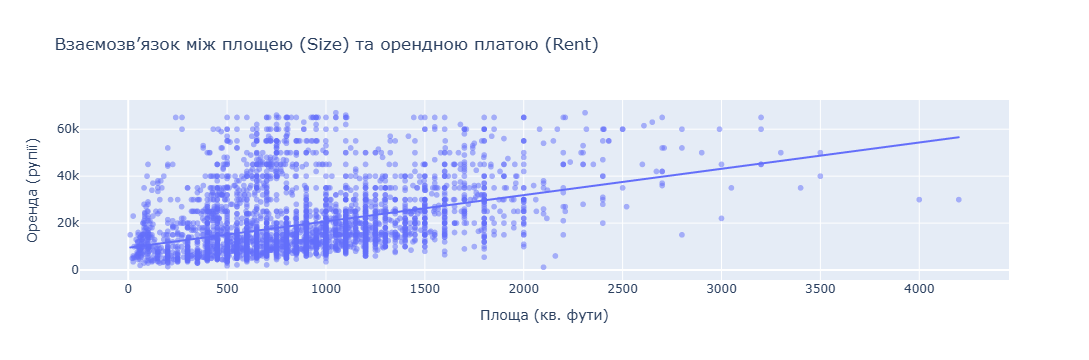

In [16]:
#Побудуйте scatter plot між Size та Rent
fig = px.scatter(
    data_cleaned, 
    x='Size', 
    y='Rent', 
    trendline="ols", 
    title='Взаємозв’язок між площею (Size) та орендною платою (Rent)',
    labels={'Size': 'Площа (кв. фути)', 'Rent': 'Оренда (рупії)'},
    opacity=0.5
)
fig.show()

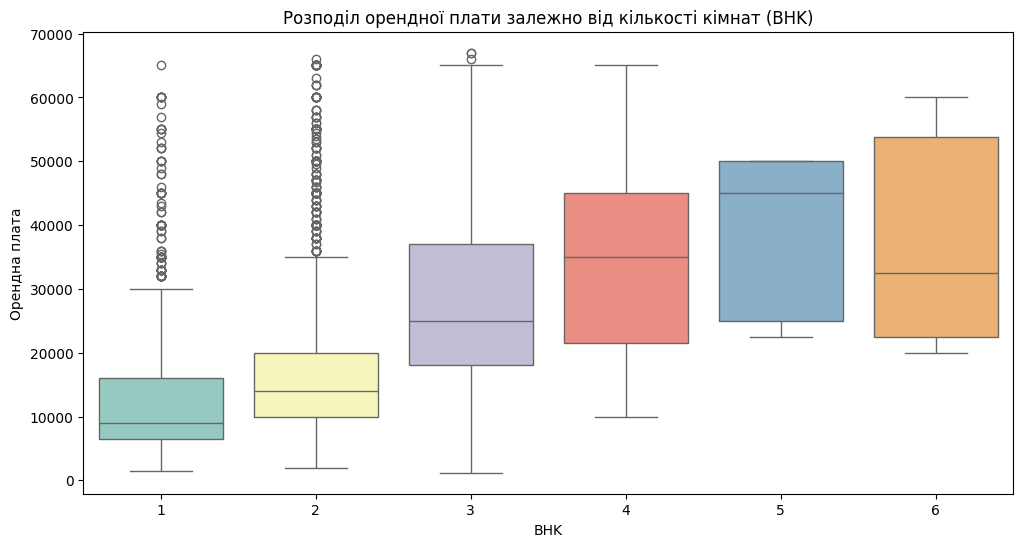

In [17]:
#Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)
plt.figure(figsize=(12, 6))
sns.boxplot(x='BHK', y='Rent', data=data_cleaned, hue='BHK', palette='Set3', legend=False)
plt.title('Розподіл орендної плати залежно від кількості кімнат (BHK)')
plt.xlabel('BHK')
plt.ylabel('Орендна плата')
plt.show()

Спостерігається чітка тенденція: чим більше кімнат у квартирі, тим вищою стає медіанна вартість оренди.
Розкид цін відносно невеликий, а самі квартири зосереджені в нижньому ціновому сегменті.
Починаючи з 3-BHK, "коробки" стають вищими. Це каже про те, що ринок великих квартир дуже різноманітний: є як бюджетні варіанти, так і дорогі.
На графіку видно багато окремих точок над "вусами" для категорій 1, 2 та 3 BHK. Це означає, що навіть серед невеликих квартир є ексклюзивні пропозиції, ціна яких значно перевищує типову для цього сегменту.

Медіана для 6-BHK виявилася нижчою, ніж для 5 кімнат. Найімовірніше, у датасеті дуже мало оголошень з 6 спальнями, і ці конкретні об'єкти розташовані у дешевших містах або районах.

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [18]:
#One-Hot Encoding
cols_to_encode = ['City', 'Furnishing Status', 'Tenant Preferred', 'Area Type']
data_encoded = pd.get_dummies(data_cleaned,columns=cols_to_encode, dtype=int)

#Виключення непотрібних колонок
data_final = data_encoded.drop(columns=['Posted On','Area Locality', 'Floor', 'Point of Contact'])
data_final.head()

,BHK,Rent,Size,Bathroom,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Furnishing Status_Furnished,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,Area Type_Built Area,Area Type_Carpet Area,Area Type_Super Area
0,2,10000,1100,2,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1
1,2,20000,800,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1
2,2,17000,1000,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1
3,2,10000,800,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1
4,2,7500,850,1,0,0,0,0,1,0,0,0,1,1,0,0,0,1,0


In [19]:
#Нові ознаки
#Площа на одну кімнату
data_final['Size_per_BHK'] = data_final['Size'] / data_final['BHK']

#Співвідношення ванних кімнат до спалень
data_final['Bath_per_BHK'] = data_final['Bathroom'] / data_final['BHK']

data_final.head()

,BHK,Rent,Size,Bathroom,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,...,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,Area Type_Built Area,Area Type_Carpet Area,Area Type_Super Area,Size_per_BHK,Bath_per_BHK
0,2,10000,1100,2,0,0,0,0,1,0,...,0,1,0,1,0,0,0,1,550.0,1.0
1,2,20000,800,1,0,0,0,0,1,0,...,1,0,0,1,0,0,0,1,400.0,0.5
2,2,17000,1000,1,0,0,0,0,1,0,...,1,0,0,1,0,0,0,1,500.0,0.5
3,2,10000,800,1,0,0,0,0,1,0,...,0,1,0,1,0,0,0,1,400.0,0.5
4,2,7500,850,1,0,0,0,0,1,0,...,0,1,1,0,0,0,1,0,425.0,0.5


In [20]:
data_final.columns

Index(['BHK', 'Rent', 'Size', 'Bathroom', 'City_Bangalore', 'City_Chennai',
       'City_Delhi', 'City_Hyderabad', 'City_Kolkata', 'City_Mumbai',
       'Furnishing Status_Furnished', 'Furnishing Status_Semi-Furnished',
       'Furnishing Status_Unfurnished', 'Tenant Preferred_Bachelors',
       'Tenant Preferred_Bachelors/Family', 'Tenant Preferred_Family',
       'Area Type_Built Area', 'Area Type_Carpet Area', 'Area Type_Super Area',
       'Size_per_BHK', 'Bath_per_BHK'],
      dtype='str')

In [21]:
#Розділіть дані на ознаки (X) та цільову змінну (y)

y = data_final['Rent'] #Цільова змінна
X = data_final.drop(columns=['Rent']) #Ознаки

print(f"Розмір X: {X.shape}")
print(f"Розмір y: {y.shape}")

Розмір X: (4226, 20)
Розмір y: (4226,)


In [22]:
#Стандартизація
num_cols = ['BHK', 'Size', 'Bathroom', 'Size_per_BHK', 'Bath_per_BHK']
scaler = StandardScaler()

X[num_cols] = scaler.fit_transform(X[num_cols])

X.head()

,BHK,Size,Bathroom,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Furnishing Status_Furnished,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,Area Type_Built Area,Area Type_Carpet Area,Area Type_Super Area,Size_per_BHK,Bath_per_BHK
0,0.052966,0.469859,0.272578,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0.604132,0.147328
1,0.052966,-0.147778,-1.133910,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,-0.268747,-1.637671
2,0.052966,0.263980,-1.133910,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0.313173,-1.637671
3,0.052966,-0.147778,-1.133910,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,-0.268747,-1.637671
4,0.052966,-0.044839,-1.133910,0,0,0,0,1,0,0,0,1,1,0,0,0,1,0,-0.123267,-1.637671


## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [23]:
#Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Кількість рядків для навчання: {X_train.shape[0]}")
print(f"Кількість рядків для тесту: {X_test.shape[0]}")

Кількість рядків для навчання: 3380
Кількість рядків для тесту: 846


In [30]:
#Створіть модель лінійної регресії.
model = LinearRegression()

#Навчіть модель на навчальних даних.
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
# Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
weights = pd.DataFrame({
    'Ознака': X.columns,
    'Коефіцієнт (Вага)': model.coef_
})

# Сортуємо за силою впливу
weights['Абсолютна вага'] = weights['Коефіцієнт (Вага)'].abs()
weights_sorted = weights.sort_values(by='Абсолютна вага', ascending=False).drop(columns=['Абсолютна вага'])

print("--------------------КОЕФІЦІЄНТИ МОДЕЛІ---------------------")
print(weights_sorted)

--------------------КОЕФІЦІЄНТИ МОДЕЛІ---------------------
                               Ознака  Коефіцієнт (Вага)
8                         City_Mumbai       19694.883087
7                        City_Kolkata       -6296.318914
6                      City_Hyderabad       -6021.299789
2                            Bathroom        4800.279955
4                        City_Chennai       -4747.591025
1                                Size        4018.670903
3                      City_Bangalore       -3107.958661
9         Furnishing Status_Furnished        2732.800264
17               Area Type_Super Area       -2183.500199
11      Furnishing Status_Unfurnished       -2087.848452
19                       Bath_per_BHK       -2035.246794
12         Tenant Preferred_Bachelors        1382.579610
14            Tenant Preferred_Family       -1335.609322
15               Area Type_Built Area        1310.429592
16              Area Type_Carpet Area         873.070607
10   Furnishing Status_Semi-

Найбільший вплив на прогноз мають ознаки City_Mumbai та City_Kolkata. Це вказує на те, що територіальний чинник є більш вагомим для визначення ціни оренди в даному датасеті, ніж розмір чи кількість кімнат

In [28]:
#Зробіть прогнози на тренувальній та тестовій вибірках.
# Прогноз на навчальній вибірці
y_train_pred = model.predict(X_train)

# Прогноз на тестовій вибірці
y_test_pred = model.predict(X_test)

# Порівняння
comparison_df = pd.DataFrame({
    'Actual Rent': y_test.values, 
    'Predicted Rent': y_test_pred,
    'Помилка': (y_test.values - y_test_pred)
}).round(2)

print("Перші 10 прогнозів на тестовій вибірці:")
print(comparison_df.head(10))

Перші 10 прогнозів на тестовій вибірці:
   Actual Rent  Predicted Rent  Помилка
0        22000        30796.48 -8796.48
1         5000         2291.35  2708.65
2        37000        37981.58  -981.58
3         8000         2009.93  5990.07
4        15000        15773.51  -773.51
5        20000        25301.40 -5301.40
6         8500        13987.92 -5487.92
7         7000         4170.09  2829.91
8         3000         -745.81  3745.81
9         8000         5905.24  2094.76


## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [38]:
#Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
def print_metrics(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- Метрики для {label} ---")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}\n")

print_metrics(y_train, y_train_pred, "навчальної вибірки (Train)")
print_metrics(y_test, y_test_pred, "тестової вибірки (Test)")

--- Метрики для навчальної вибірки (Train) ---
MAE:  5933.78
RMSE: 8197.93
R²:   0.6480

--- Метрики для тестової вибірки (Test) ---
MAE:  5911.48
RMSE: 8173.54
R²:   0.6516



Модель показує схожі результати на обох вибірках ($R^2 \approx 0.65$), що свідчить про відсутність перенавчання. Середня помилка становить близько 5900 рупій.

Модель демонструє ознаки недонавчання, є занадто простою, щоб вловити всі нюанси даних.
Високий RMSE (8173) порівняно з MAE (5911) підтверджує, що модель часто помиляється на великі суми там, де ціна квартири сильно вибивається із загальних правил.

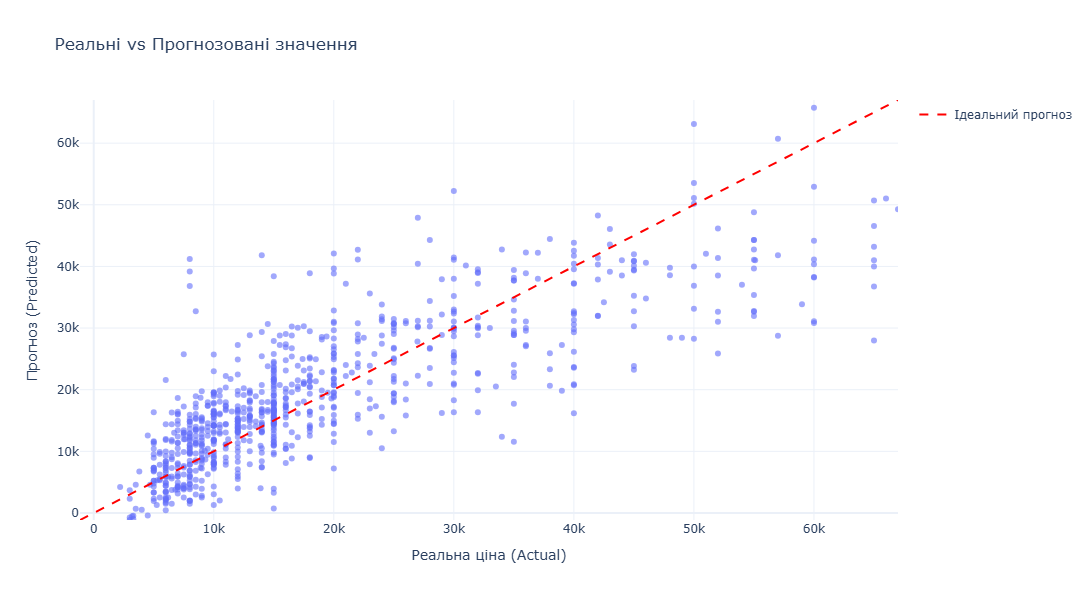

In [42]:
#Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

fig = px.scatter(
    x=y_test,
    y=y_test_pred,
    title='Реальні vs Прогнозовані значення',
    labels={'x': 'Реальна ціна (Actual)', 'y': 'Прогноз (Predicted)'},
    opacity=0.6,
    template='plotly_white'
)

fig.add_trace(
    go.Scatter(
        x=[min_val, max_val],
        y=[min_val, max_val],
        mode='lines',
        name='Ідеальний прогноз',
        line=dict(color='red', dash='dash', width=2)
    )
)

fig.update_layout(
    height=600,
    width=700,
    xaxis=dict(range=[min_val, max_val]),
    yaxis=dict(range=[min_val, max_val]),
    showlegend=True
)

fig.show()

Точки вишикувані вздовж діагональної лінії. Це підтверджує, що модель працює правильно. Бачимо досить широке розсіювання, що вказує на недостатню точність прогноування. Точки розподілені приблизно однаково як над лінією, так і під нею, що вказує на те що модель помиляється в обидва боки.
Зона низьких цін (до 20k) має найбільшу концентрацію точок й можна сказати, що модель непогано вгадує «масовий сегмент». Зона високих цін (понад 40k) має менше точок, і вони сильніше віддаляються від лінії. Моделі важче прогнозувати дорогу нерухомість, бо там ціна часто залежить від розкоші чи унікальності.

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

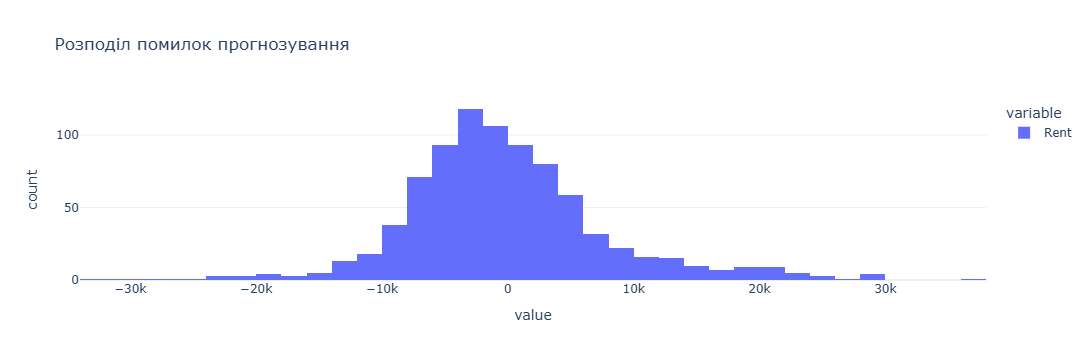

In [48]:
#Обчисліть помилки (residuals = реальні - прогнозовані значення)
residuals = y_test - y_test_pred

#Побудуйте гістограму розподілу помилок
fig_hist = px.histogram(
    residuals, 
    nbins=50, 
    title='Розподіл помилок прогнозування',
    labels={'x': 'Помилка (реальні - прогнозовані)', 'count': 'Кількість'},
    template='plotly_white'
)
fig.add_vline(x=0, line_dash="dash", line_color="black", annotation_text="Ідеальний прогноз")
fig.update_layout(height=400)
fig_hist.show()

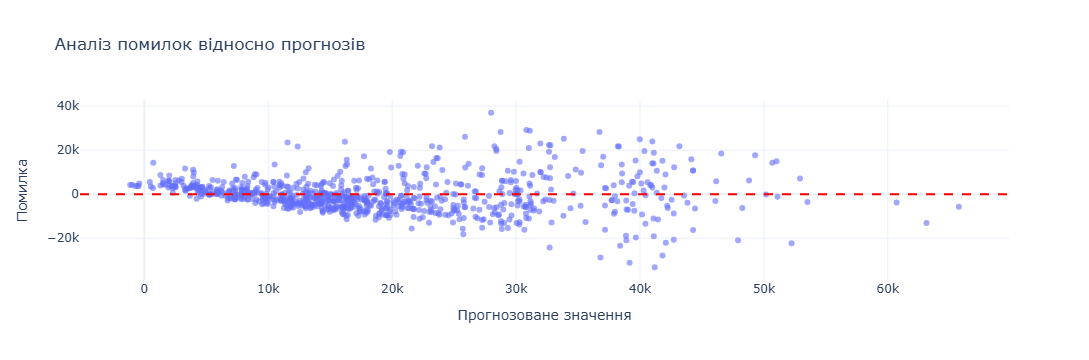

In [49]:
#Створіть scatter plot помилок відносно величини прогнозованих значень.
fig_res = px.scatter(
    x=y_test_pred, 
    y=residuals,
    title='Аналіз помилок відносно прогнозів',
    labels={'x': 'Прогнозоване значення', 'y': 'Помилка'},
    opacity=0.6,
    template='plotly_white'
)

fig_res.add_hline(y=0, line_dash="dash", line_color="red")
fig_res.show()

 **Чи росте помилка з ростом прогнозованого значення?**

 Так, амплітуда помилок збільшується разом із ростом прогнозованої ціни.

In [52]:
# Знайдіть 5 прогнозів з найбільшими помилками
errors_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_test_pred,
    'absolute_error': np.abs(residuals)
})

top_errors = errors_df.nlargest(5, 'absolute_error') 

print("Прогнози з найбільшими помилками прогнозування:")
print(top_errors)

Прогнози з найбільшими помилками прогнозування:
      actual     predicted  absolute_error
3520   65000  27987.563063    37012.436937
852     8000  41192.740834    33192.740834
549     8000  39163.422005    31163.422005
809    60000  30832.294930    29167.705070
2658   60000  31112.246451    28887.753549


**Проаналізуйте, на яких типах житла модель помиляється найбільше**

Найбільші помилки в Мумбаї. Оскільки там найвищі ціни, будь-яке відхилення у відсотках дає величезну суму в рупіях.

Модель часто помиляється на 3-BHK та елітному житлі, а також на квартирах з дуже великою площею, де ціна може залежати від престижності будинку, а не лише від метрів.

**Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі.**

Логарифмування цільової змінної.

Краще очищення від аномалій.

Зміна алгоритму.

In [57]:
# Логарифмування цільової змінної.
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

#Створюємо та навчаємо нову модель
model_log = LinearRegression()
model_log.fit(X_train, y_train_log)

#Робимо прогноз на тестовій вибірці (отримаємо значення в логарифмах)
y_test_pred_log = model_log.predict(X_test)

#Повертаємо прогноз до реальних грошей
y_test_pred_final = np.expm1(y_test_pred_log)

print("--- Метрики ПІСЛЯ Log Transformation ---")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_final):.2f}")
print(f"R²:  {r2_score(y_test, y_test_pred_final):.4f}")

--- Метрики ПІСЛЯ Log Transformation ---
MAE: 5676.18
R²:  0.5137


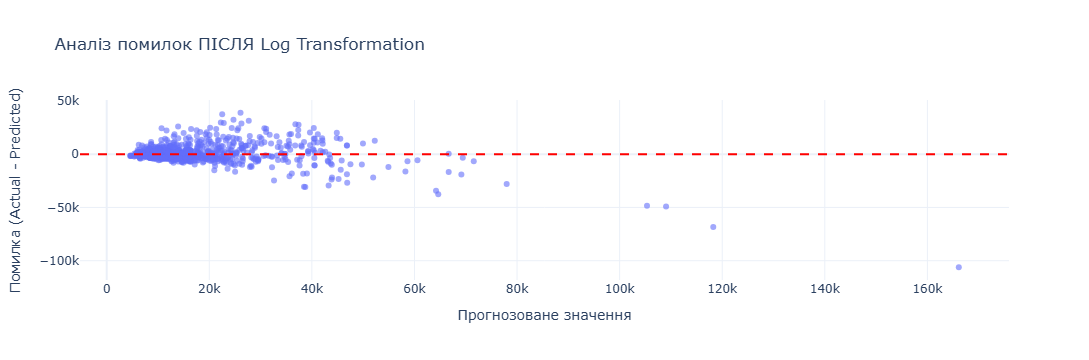

In [59]:
#Перераховуємо помилки для нової моделі
residuals_final = y_test - y_test_pred_final

#Графік
fig_res = px.scatter(
    x=y_test_pred_final,
    y=residuals_final,
    title='Аналіз помилок ПІСЛЯ Log Transformation',
    labels={'x': 'Прогнозоване значення', 'y': 'Помилка (Actual - Predicted)'},
    opacity=0.6,
    template='plotly_white'
)

fig_res.add_hline(y=0, line_dash="dash", line_color="red")
fig_res.show()


Тепер прогнози починаються від 0 і йдуть вправо, що робить модель логічно правильною.
Основна хмара помилок стала значно щільнішою - модель стала краще вгадувати ціну для більшості звичайних квартир. Модель почала видавати дуже високі прогнози для деяких об'єктів, і там помилка стала від'ємною. Це означає, що для елітного сегмента логарифмічна модель іноді прогнозуює занадто високу ціну.
